In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
uploaded = files.upload()

Saving water_dataX.csv to water_dataX.csv


In [ ]:
df = pd.read_csv("water_dataX.csv", encoding='latin-1')

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset Shape: (1991, 12)

Columns:
['STATION CODE', 'LOCATIONS', 'STATE', 'Temp', 'D.O. (mg/l)', 'PH', 'CONDUCTIVITY (µmhos/cm)', 'B.O.D. (mg/l)', 'NITRATENAN N+ NITRITENANN (mg/l)', 'FECAL COLIFORM (MPN/100ml)', 'TOTAL COLIFORM (MPN/100ml)Mean', 'year']


,STATION CODE,LOCATIONS,STATE,Temp,D.O. (mg/l),PH,CONDUCTIVITY (µmhos/cm),B.O.D. (mg/l),NITRATENAN N+ NITRITENANN (mg/l),FECAL COLIFORM (MPN/100ml),TOTAL COLIFORM (MPN/100ml)Mean,year
0,1393,"DAMANGANGA AT D/S OF MADHUBAN, DAMAN",DAMAN & DIU,30.6,6.7,7.5,203,NAN,0.1,11,27,2014
1,1399,ZUARI AT D/S OF PT. WHERE KUMBARJRIA CANAL JOI...,GOA,29.8,5.7,7.2,189,2,0.2,4953,8391,2014
2,1475,ZUARI AT PANCHAWADI,GOA,29.5,6.3,6.9,179,1.7,0.1,3243,5330,2014
3,3181,RIVER ZUARI AT BORIM BRIDGE,GOA,29.7,5.8,6.9,64,3.8,0.5,5382,8443,2014
4,3182,RIVER ZUARI AT MARCAIM JETTY,GOA,29.5,5.8,7.3,83,1.9,0.4,3428,5500,2014


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1991 entries, 0 to 1990
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   STATION CODE                      1991 non-null   object
 1   LOCATIONS                         1991 non-null   object
 2   STATE                             1991 non-null   object
 3   Temp                              1991 non-null   object
 4   D.O. (mg/l)                       1991 non-null   object
 5   PH                                1991 non-null   object
 6   CONDUCTIVITY (µmhos/cm)           1991 non-null   object
 7   B.O.D. (mg/l)                     1991 non-null   object
 8   NITRATENAN N+ NITRITENANN (mg/l)  1991 non-null   object
 9   FECAL COLIFORM (MPN/100ml)        1991 non-null   object
 10  TOTAL COLIFORM (MPN/100ml)Mean    1991 non-null   object
 11  year                              1991 non-null   int64 
dtypes: int64(1), object(

In [ ]:
print("Missing Values:")
display(df.isnull().sum())

Missing Values:


,0
STATION CODE,0
LOCATIONS,0
STATE,0
Temp,0
D.O. (mg/l),0
PH,0
CONDUCTIVITY (µmhos/cm),0
B.O.D. (mg/l),0
NITRATENAN N+ NITRITENANN (mg/l),0
FECAL COLIFORM (MPN/100ml),0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1


In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (1990, 12)


In [ ]:
for column in df.columns:
    print(column)

STATION CODE
LOCATIONS
STATE
Temp
D.O. (mg/l)
PH
CONDUCTIVITY (µmhos/cm)
B.O.D. (mg/l)
NITRATENAN N+ NITRITENANN (mg/l)
FECAL COLIFORM (MPN/100ml)
TOTAL COLIFORM (MPN/100ml)Mean
year


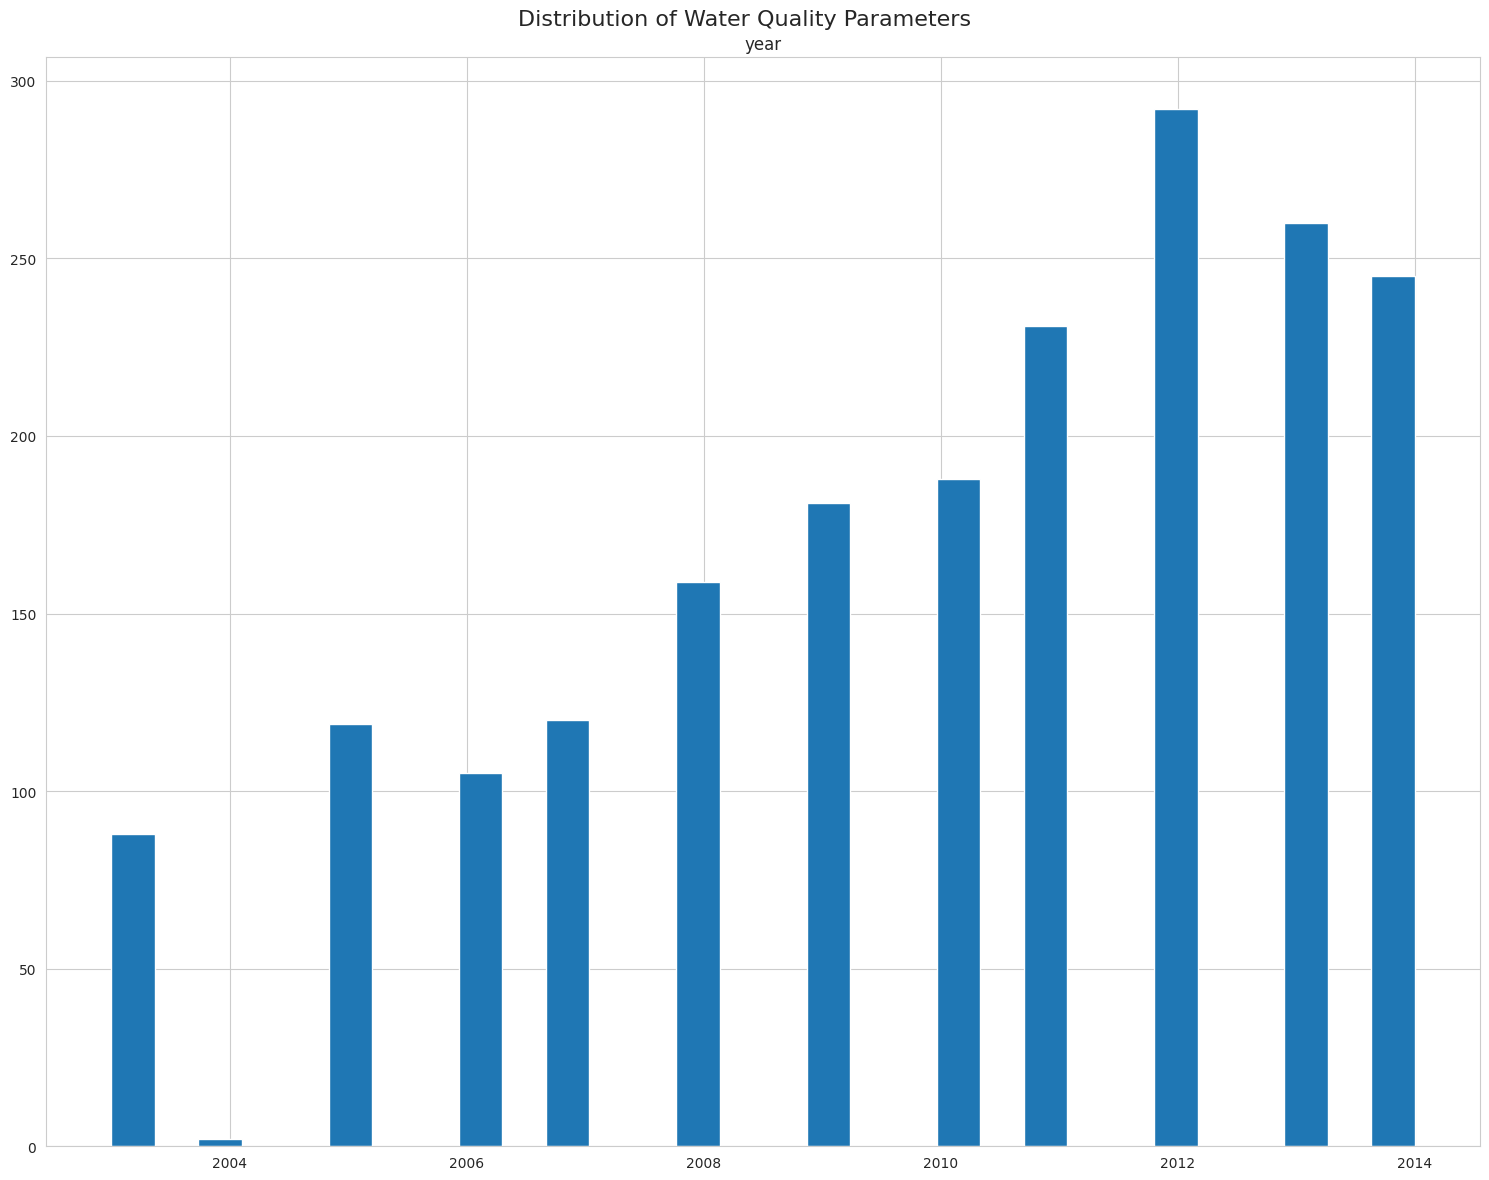

In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].hist(
    figsize=(15, 12),
    bins=30
)

plt.suptitle("Distribution of Water Quality Parameters", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
print(df.columns.tolist())

['STATION CODE', 'LOCATIONS', 'STATE', 'Temp', 'D.O. (mg/l)', 'PH', 'CONDUCTIVITY (µmhos/cm)', 'B.O.D. (mg/l)', 'NITRATENAN N+ NITRITENANN (mg/l)', 'FECAL COLIFORM (MPN/100ml)', 'TOTAL COLIFORM (MPN/100ml)Mean', 'year']


In [ ]:
df = df.rename(columns={
    'STATION CODE': 'Station_Code',
    'LOCATIONS': 'Location',
    'STATE': 'State',
    'Temp': 'Temperature',
    'D.O. (mg/l)': 'DO',
    'PH': 'pH',
    'CONDUCTIVITY (µmhos/cm)': 'Conductivity',
    'B.O.D. (mg/l)': 'BOD',
    'NITRATENAN N+ NITRITENANN (mg/l)': 'Nitrate_Nitrite',
    'FECAL COLIFORM (MPN/100ml)': 'Fecal_Coliform',
    'TOTAL COLIFORM (MPN/100ml)Mean': 'Total_Coliform',
    'year': 'Year'
})

print(df.columns.tolist())

['Station_Code', 'Location', 'State', 'Temperature', 'DO', 'pH', 'Conductivity', 'BOD', 'Nitrate_Nitrite', 'Fecal_Coliform', 'Total_Coliform', 'Year']


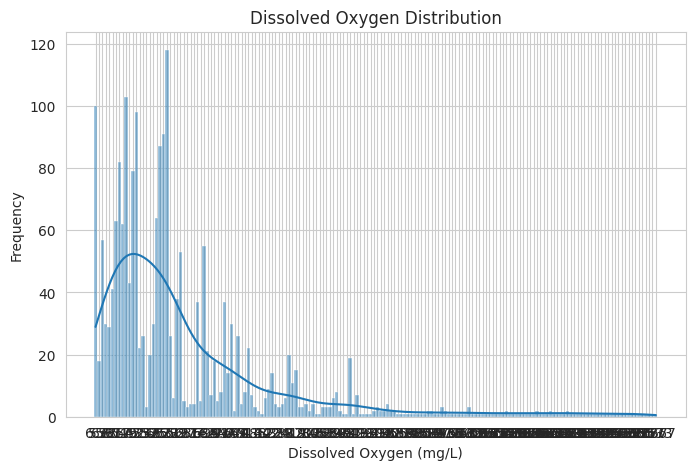

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='DO',
    kde=True
)

plt.title("Dissolved Oxygen Distribution")
plt.xlabel("Dissolved Oxygen (mg/L)")
plt.ylabel("Frequency")

plt.show()

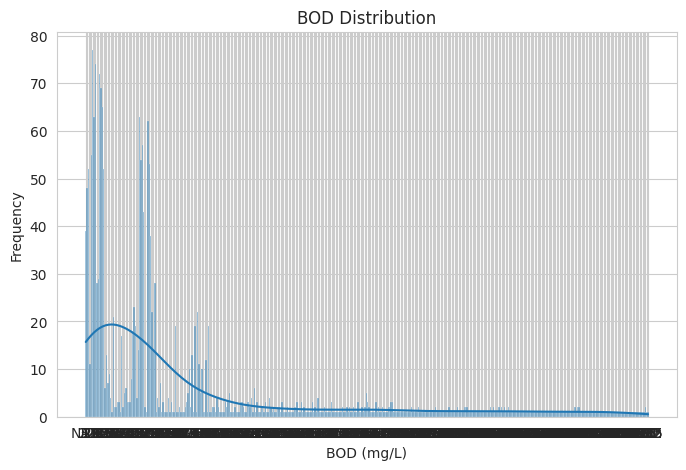

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='BOD',
    kde=True
)

plt.title("BOD Distribution")
plt.xlabel("BOD (mg/L)")
plt.ylabel("Frequency")

plt.show()

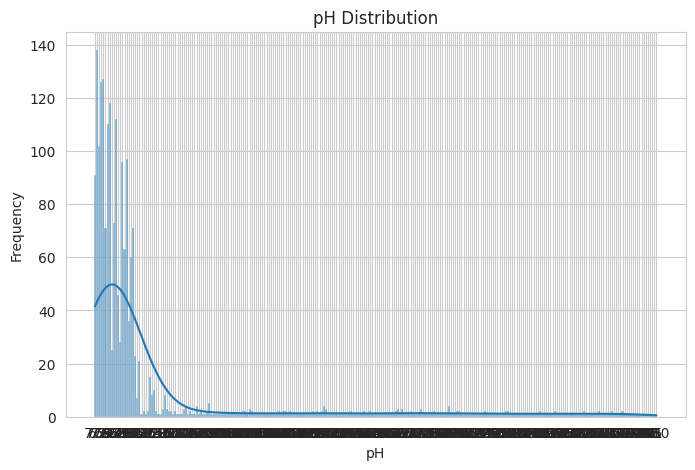

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='pH',
    kde=True
)

plt.title("pH Distribution")
plt.xlabel("pH")
plt.ylabel("Frequency")

plt.show()

In [ ]:
def calculate_quality_score(row):

    score = 0

    # pH
    if 6.5 <= row['pH'] <= 8.5:
        score += 1

    # Dissolved Oxygen
    if row['DO'] >= 5:
        score += 1

    # BOD
    if row['BOD'] <= 3:
        score += 1

    # Nitrate + Nitrite
    if row['Nitrate_Nitrite'] <= 10:
        score += 1

    # Fecal Coliform
    if row['Fecal_Coliform'] <= 100:
        score += 1

    # Total Coliform
    if row['Total_Coliform'] <= 500:
        score += 1

    return score

In [ ]:
numeric_cols = [
    'Temperature', 'DO', 'pH', 'Conductivity', 'BOD',
    'Nitrate_Nitrite', 'Fecal_Coliform', 'Total_Coliform'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill NaN values with 0 after conversion, or choose an appropriate imputation strategy
df[numeric_cols] = df[numeric_cols].fillna(0)

df['Quality_Score'] = df.apply(
    calculate_quality_score,
    axis=1
)

display(
    df[['Quality_Score']].head(10)
)

,Quality_Score
0,6
1,4
2,4
3,3
4,4
5,4
6,4
7,4
8,4
9,4


In [ ]:
def classify_water(score):

    if score >= 5:
        return 'Good'
    elif score >= 3:
        return 'Moderate'
    else:
        return 'Poor'


df['Water_Quality'] = df['Quality_Score'].apply(
    classify_water
)

print(df['Water_Quality'].value_counts())

Water_Quality
Moderate    945
Good        924
Poor        121
Name: count, dtype: int64


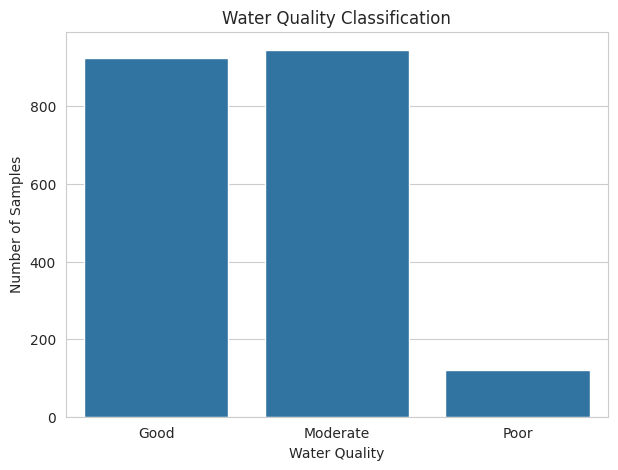

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Water_Quality',
    order=['Good', 'Moderate', 'Poor']
)

plt.title("Water Quality Classification")
plt.xlabel("Water Quality")
plt.ylabel("Number of Samples")

plt.show()

In [ ]:
features = [
    'Temperature',
    'DO',
    'pH',
    'Conductivity',
    'BOD',
    'Nitrate_Nitrite',
    'Fecal_Coliform',
    'Total_Coliform'
]

X = df[features]
y = df['Water_Quality']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1990, 8)
y shape: (1990,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1592
Testing samples: 398


In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

print("Missing values handled.")

Missing values handled.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(
    X_train_imp,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
rf_pred = rf_model.predict(X_test_imp)

print(rf_pred[:20])

['Good' 'Good' 'Moderate' 'Moderate' 'Good' 'Moderate' 'Moderate' 'Good'
 'Moderate' 'Poor' 'Good' 'Moderate' 'Moderate' 'Good' 'Moderate' 'Good'
 'Moderate' 'Moderate' 'Moderate' 'Good']


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, rf_pred))
print(
    "Precision:",
    precision_score(
        y_test,
        rf_pred,
        average='weighted'
    )
)
print(
    "Recall   :",
    recall_score(
        y_test,
        rf_pred,
        average='weighted'
    )
)
print(
    "F1 Score :",
    f1_score(
        y_test,
        rf_pred,
        average='weighted'
    )
)

Accuracy : 0.9698492462311558
Precision: 0.9705040671585352
Recall   : 0.9698492462311558
F1 Score : 0.9693305709314836


In [ ]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

        Good       0.98      0.98      0.98       185
    Moderate       0.95      0.98      0.97       189
        Poor       1.00      0.79      0.88        24

    accuracy                           0.97       398
   macro avg       0.98      0.92      0.94       398
weighted avg       0.97      0.97      0.97       398



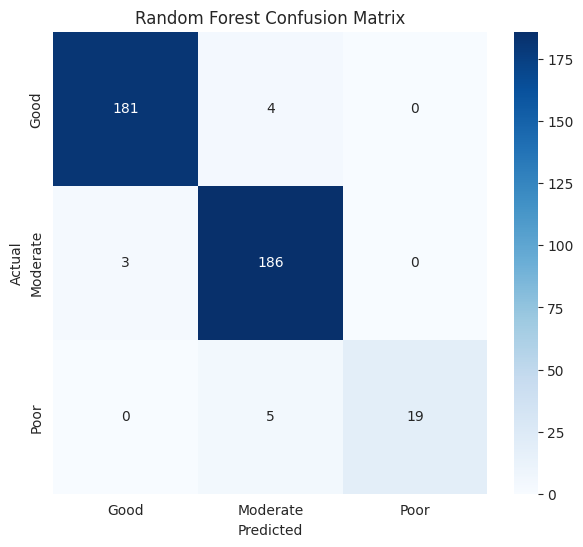

In [ ]:
cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=['Good', 'Moderate', 'Poor']
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Good', 'Moderate', 'Poor'],
    yticklabels=['Good', 'Moderate', 'Poor']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

display(importance)

,Feature,Importance
7,Total_Coliform,0.296506
1,DO,0.208213
6,Fecal_Coliform,0.163545
4,BOD,0.142623
5,Nitrate_Nitrite,0.079604
3,Conductivity,0.048763
2,pH,0.038962
0,Temperature,0.021785


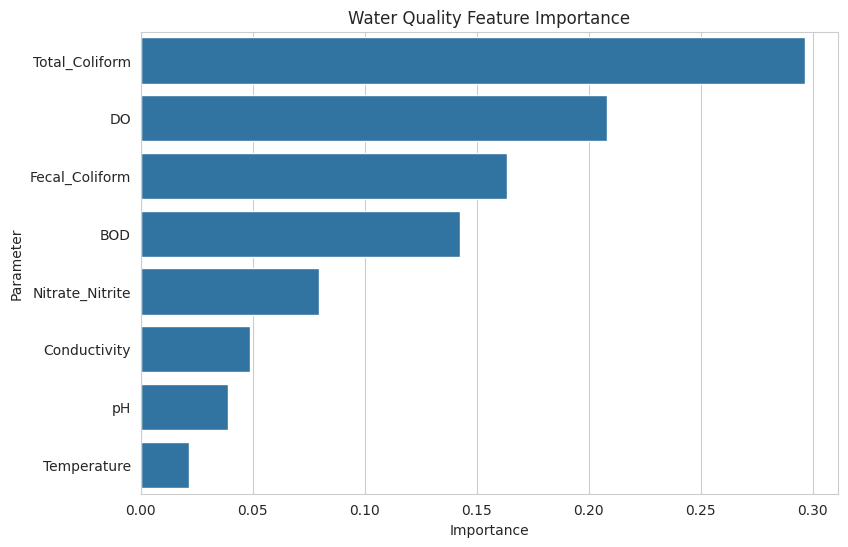

In [ ]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Water Quality Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Parameter")

plt.show()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

lr_model.fit(X_train_imp, y_train)

lr_pred = lr_model.predict(X_test_imp)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=8,
    random_state=42,
    class_weight='balanced'
)

dt_model.fit(X_train_imp, y_train)

dt_pred = dt_model.predict(X_test_imp)

In [ ]:
models = {
    'Logistic Regression': lr_pred,
    'Decision Tree': dt_pred,
    'Random Forest': rf_pred
}

results = []

for name, pred in models.items():

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(
            y_test,
            pred,
            average='weighted'
        ),
        'Recall': recall_score(
            y_test,
            pred,
            average='weighted'
        ),
        'F1 Score': f1_score(
            y_test,
            pred,
            average='weighted'
        )
    })

results_df = pd.DataFrame(results)

display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.5678,0.5768,0.5678,0.5553
1,Decision Tree,0.9899,0.9899,0.9899,0.9899
2,Random Forest,0.9698,0.9705,0.9698,0.9693


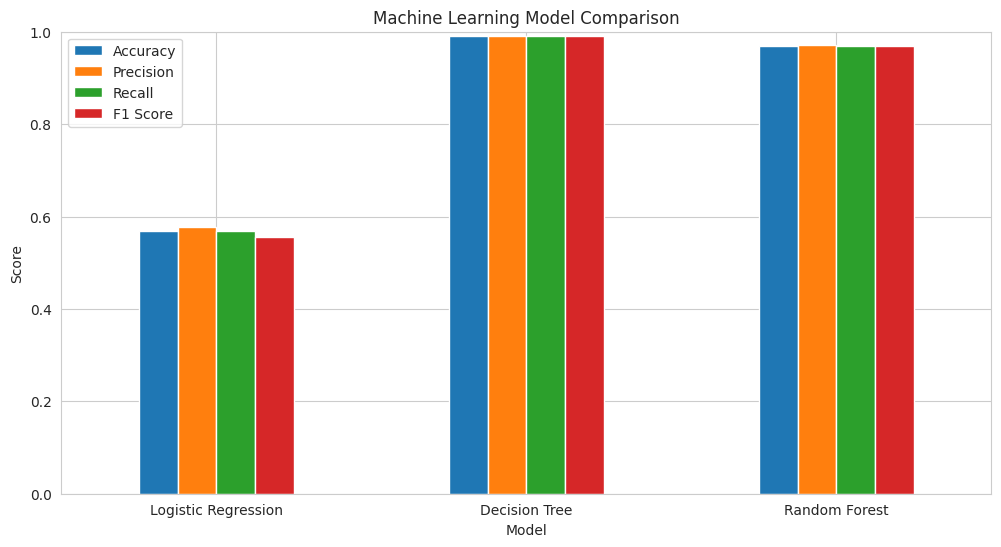

In [ ]:
results_df.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.show()

In [ ]:
sample = pd.DataFrame({
    'Temperature': [25],
    'DO': [6],
    'pH': [7.2],
    'Conductivity': [400],
    'BOD': [2],
    'Nitrate_Nitrite': [3],
    'Fecal_Coliform': [20],
    'Total_Coliform': [100]
})

sample_imp = imputer.transform(sample)

prediction = rf_model.predict(sample_imp)[0]

probabilities = rf_model.predict_proba(sample_imp)[0]

print("Predicted Water Quality:", prediction)

for label, probability in zip(
    rf_model.classes_,
    probabilities
):
    print(f"{label}: {probability:.2%}")

Predicted Water Quality: Good
Good: 99.00%
Moderate: 1.00%
Poor: 0.00%
